In [27]:
# Imports
%matplotlib inline
%config InlineBackend.figure_formats = ['svg']

import numpy as np  # Matrix and vector computation package
import matplotlib
import matplotlib.pyplot as plt  # Plotting library
from matplotlib import cm  # Colormaps
from matplotlib.colors import LogNorm
import seaborn as sns  # Fancier plots

# Set seaborn plotting style
sns.set_style('darkgrid')
# Set the seed for reproducability
np.random.seed(seed=1)

In [28]:
nb_of_samples = 30
sequence_len = 20

X = np.round(np.random.rand(nb_of_samples, sequence_len) * 5) / 5

t = np.mean(X, axis=1)

print("Pierwsza sekwencja wejściowa:\n", X[0])
print("Średnia (cel t) dla pierwszej sekwencji:", t[0])

Pierwsza sekwencja wejściowa:
 [0.4 0.8 0.  0.4 0.2 0.  0.2 0.4 0.4 0.6 0.4 0.6 0.2 0.8 0.  0.6 0.4 0.6
 0.2 0.2]
Średnia (cel t) dla pierwszej sekwencji: 0.37


In [29]:
# Define the forward step functions

def update_state(xk, sk, wx, wRec):
    """
    Compute state k from the previous state (sk) and current 
    input (xk), by use of the input weights (wx) and recursive 
    weights (wRec).
    """
    return xk * wx + sk * wRec


def forward_states(X, wx, wRec):
    """
    Unfold the network and compute all state activations 
    given the input X, input weights (wx), and recursive weights 
    (wRec). Return the state activations in a matrix, the last 
    column S[:,-1] contains the final activations.
    """
    # Initialise the matrix that holds all states for all 
    #  input sequences. The initial state s0 is set to 0.
    S = np.zeros((X.shape[0], X.shape[1]+1))
    # Use the recurrence relation defined by update_state to update 
    #  the states trough time.
    for k in range(0, X.shape[1]):
        S[:,k+1] = update_state(X[:,k], S[:,k], wx, wRec)
    return S


def loss(y, t): 
    """MSE between the targets t and the outputs y."""
    return np.mean((t - y)**2)

In [30]:
def output_gradient(y, t):
    """
    Gradient of the MSE loss function with respect to the output y.
    """
    return 2. * (y - t)


def backward_gradient(X, S, grad_out, wRec):
    """
    Backpropagate the gradient computed at the output (grad_out) 
    through the network. Accumulate the parameter gradients for 
    wX and wRec by for each layer by addition. Return the parameter 
    gradients as a tuple, and the gradients at the output of each layer.
    """
    # Initialise the array that stores the gradients of the loss with \n",
    #  respect to the states.
    grad_over_time = np.zeros((X.shape[0], X.shape[1]+1))
    grad_over_time[:,-1] = grad_out
    # Set the gradient accumulations to 0
    wx_grad = 0
    wRec_grad = 0
    for k in range(X.shape[1], 0, -1):
        # Compute the parameter gradients and accumulate the results.
        wx_grad += np.sum(
            np.mean(grad_over_time[:,k] * X[:,k-1], axis=0))
        wRec_grad += np.sum(
            np.mean(grad_over_time[:,k] * S[:,k-1]), axis=0)
        # Compute the gradient at the output of the previous layer
        grad_over_time[:,k-1] = grad_over_time[:,k] * wRec
    return (wx_grad, wRec_grad), grad_over_time

In [31]:
# Perform gradient checking
params = [1.2, 1.2]  # [wx, wRec]
eps = 1e-7

# Compute the backprop gradients
S = forward_states(X, params[0], params[1])
grad_out = output_gradient(S[:,-1], t)
backprop_grads, grad_over_time = backward_gradient(
    X, S, grad_out, params[1])

# Compute the numerical gradient for each parameter in the layer
for p_idx, _ in enumerate(params):
    grad_backprop = backprop_grads[p_idx]
    # + eps
    params[p_idx] += eps
    plus_loss = loss(forward_states(X, params[0], params[1])[:,-1], t)
    # - eps
    params[p_idx] -= 2 * eps
    min_loss = loss(forward_states(X, params[0], params[1])[:,-1], t)
    # reset param value
    params[p_idx] += eps
    # calculate numerical gradient
    grad_num = (plus_loss - min_loss) / (2*eps)
    
    if not np.isclose(grad_num, grad_backprop):
        raise ValueError((
            f'Numerical gradient of {grad_num:.6f} is not close to '
            f'the backpropagation gradient of {grad_backprop:.6f}!'))
print('No gradient errors found')

No gradient errors found


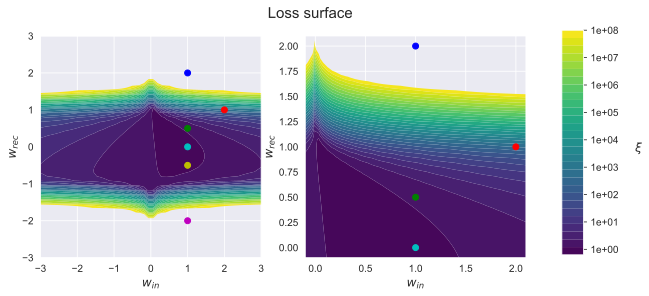

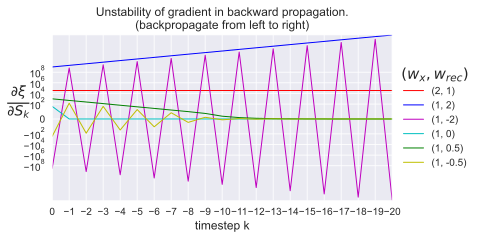

In [32]:
# Define plotting functions
points = [(2,1,'r'), (1,2,'b'), (1,-2,'m'), (1,0,'c'), 
          (1,0.5,'g'), (1,-0.5,'y')]

def get_loss_surface(w1_low, w1_high, w2_low, w2_high, 
                     nb_of_ws, loss_func):
    w1 = np.linspace(w1_low, w1_high, num=nb_of_ws)  # Weight 1
    w2 = np.linspace(w2_low, w2_high, num=nb_of_ws)  # Weight 2
    ws1, ws2 = np.meshgrid(w1, w2)  # Generate grid
    loss_ws = np.zeros((nb_of_ws, nb_of_ws))  # Initialize loss matrix
    for i in range(nb_of_ws):
        for j in range(nb_of_ws):
            loss_ws[i,j] = loss_func(ws1[i,j], ws2[i,j])
    return ws1, ws2, loss_ws

def plot_surface(ax, ws1, ws2, loss_ws):
    surf = ax.contourf(
        ws1, ws2, loss_ws, levels=np.logspace(-0.2, 8, 30), 
        cmap=cm.viridis, norm=LogNorm())
    ax.set_xlabel('$w_{in}$', fontsize=12)
    ax.set_ylabel('$w_{rec}$', fontsize=12)
    return surf

def plot_points(ax, points):
    for wx, wRec, c in points:
        ax.plot(wx, wRec, c+'o', linewidth=2)
        
def get_loss_surface_figure(loss_func, points):
    fig = plt.figure(figsize=(10, 4))   
    ax_1 = fig.add_subplot(1,2,1)
    ws1_1, ws2_1, loss_ws_1 = get_loss_surface(-3, 3, -3, 3, 50, loss_func)
    surf_1 = plot_surface(ax_1, ws1_1, ws2_1, loss_ws_1 + 1)
    plot_points(ax_1, points)
    ax_1.set_xlim(-3, 3)
    ax_1.set_ylim(-3, 3)
    
    ax_2 = fig.add_subplot(1,2,2)
    ws1_2, ws2_2, loss_ws_2 = get_loss_surface(-0.1, 2.1, -0.1, 2.1, 50, loss_func)
    surf_2 = plot_surface(ax_2, ws1_2, ws2_2, loss_ws_2 + 1)
    plot_points(ax_2, points)
    ax_2.set_xlim(-0.1, 2.1)
    ax_2.set_ylim(-0.1, 2.1)
    
    fig.subplots_adjust(right=0.8)
    cax = fig.add_axes([0.85, 0.12, 0.03, 0.78])
    cbar = fig.colorbar(surf_1, ticks=np.logspace(0, 8, 9), cax=cax)
    
    cbar.ax.set_ylabel(r'$\xi$', fontsize=12, rotation=0, labelpad=20)
    
    cbar.set_ticklabels(['{:.0e}'.format(i) for i in np.logspace(0, 8, 9)])
    fig.suptitle('Loss surface', fontsize=15)
    return fig

def plot_gradient_over_time(points, get_grad_over_time):
    fig = plt.figure(figsize=(7, 3))
    ax = plt.subplot(111)
    for wx, wRec, c in points:
        grad_over_time = get_grad_over_time(wx, wRec)
        x = np.arange(-grad_over_time.shape[1]+1, 1, 1)
        plt.plot(
            x, np.sum(grad_over_time, axis=0), c+'-', 
            label=f'({wx}, {wRec})', linewidth=1, markersize=8)
    plt.xlim(0, -grad_over_time.shape[1]+1)
    plt.xticks(x)
    plt.yscale('symlog')
    plt.yticks([10**8, 10**6, 10**4, 10**2, 0, -10**2, -10**4, -10**6, -10**8])
    plt.xlabel('timestep k', fontsize=12)
    
    plt.ylabel(r'$\frac{\partial \xi}{\partial S_{k}}$', fontsize=20, rotation=0)
    
    plt.title('Unstability of gradient in backward propagation.\n(backpropagate from left to right)')
    leg = plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=False, numpoints=1)
    leg.set_title('$(w_x, w_{rec})$', prop={'size':15})
    fig.subplots_adjust(right=0.8)
    
def get_grad_over_time(wx, wRec):
    S = forward_states(X, wx, wRec)
    grad_out = output_gradient(S[:,-1], t).sum()
    _, grad_over_time = backward_gradient(X, S, grad_out, wRec)
    return grad_over_time

fig = get_loss_surface_figure(lambda w1, w2: loss(forward_states(X, w1, w2)[:,-1] , t), points)
plot_gradient_over_time(points, get_grad_over_time)
plt.show()

In [33]:
def update_rprop(X, t, W, W_prev_sign, W_delta, eta_p, eta_n):
    """
    Update RProp values in one iteration.
    """
    S = forward_states(X, W[0], W[1])
    grad_out = output_gradient(S[:,-1], t)
    W_grads, _ = backward_gradient(X, S, grad_out, W[1])
    W_sign = np.sign(W_grads) # Sign of new gradient
    
    for i, _ in enumerate(W):
        if W_sign[i] == W_prev_sign[i]:
            W_delta[i] *= eta_p
        else:
            W_delta[i] *= eta_n
    return W_delta, W_sign

In [34]:
# Perform Rprop optimisation pod zadanie 11

# Hiperparametrs
eta_p = 1.2
eta_n = 0.5

W = [-0.5, 1.5] # [wx, wRec]
W_delta = [0.001, 0.001] #[delta_wx, delta_wRec]
W_sign = [0, 0]

ls_of_ws = [(W[0], W[1])]

# 500 iterations
for i in range(500):
    
    W_delta, W_sign = update_rprop(X, t, W, W_sign, W_delta, eta_p, eta_n)
    
    for idx, _ in enumerate(W):
        W[idx] -= W_sign[idx] * W_delta[idx]
        
    ls_of_ws.append((W[0], W[1]))

print(f'Ostateczne wyuczone wagi to: wx = {W[0]:.4f}, wRec = {W[1]:.4f}')
print(f'Oczekiwane wagi teoretyczne: wx = {1/sequence_len:.2f} (0.05), wRec = 1.00')

Ostateczne wyuczone wagi to: wx = 0.0627, wRec = 0.9752
Oczekiwane wagi teoretyczne: wx = 0.05 (0.05), wRec = 1.00
